**Context**:

The biggest challenge of Factoring is to predict if and when invoices will be paid. The factor provides funds against this future payment to the business by buying their invoice. The factor then collects the payment and charges their interest rate. If the invoice isn't paid, the factor loses their advanced funds. Try using this data set for predicting when payments will be made.**

Accounts Receivable
Understand the factors of successful collection efforts. You can Predict which customers will pay fastest and recover more money and improve collections efficiency.

In [ ]:
!pip install sklearn
!pip install --upgrade pip
!pip install scikit-learn


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [1]:
import math
import numpy as np
import pandas as pd
from datetime import datetime
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
#plt.style.use('seaborn-whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor,  GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
#import statsmodels.api as sm

#### Get the Data

In [2]:

df_receivable = pd.read_csv('C:/Users/rborehal/Desktop/Rohith/31_Vertex_AI_Training/1_dataset/WA_Fn-UseC_-Accounts-Receivable.csv')
#df.dropna(inplace=True)
df_receivable.info()

<class 'pandas.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   countryCode    2466 non-null   int64  
 1   customerID     2466 non-null   str    
 2   PaperlessDate  2466 non-null   str    
 3   invoiceNumber  2466 non-null   int64  
 4   InvoiceDate    2466 non-null   str    
 5   DueDate        2466 non-null   str    
 6   InvoiceAmount  2466 non-null   float64
 7   Disputed       2466 non-null   str    
 8   SettledDate    2466 non-null   str    
 9   PaperlessBill  2466 non-null   str    
 10  DaysToSettle   2466 non-null   int64  
 11  DaysLate       2466 non-null   int64  
dtypes: float64(1), int64(4), str(7)
memory usage: 231.3 KB


In [3]:
df_receivable.head(5)

,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate
0,391,0379-NEVHP,4/6/2013,611365,1/2/2013,2/1/2013,55.94,No,1/15/2013,Paper,13,0
1,406,8976-AMJEO,3/3/2012,7900770,1/26/2013,2/25/2013,61.74,Yes,3/3/2013,Electronic,36,6
2,391,2820-XGXSB,1/26/2012,9231909,7/3/2013,8/2/2013,65.88,No,7/8/2013,Electronic,5,0
3,406,9322-YCTQO,4/6/2012,9888306,2/10/2013,3/12/2013,105.92,No,3/17/2013,Electronic,35,5
4,818,6627-ELFBK,11/26/2012,15752855,10/25/2012,11/24/2012,72.27,Yes,11/28/2012,Paper,34,4


In [4]:
df_receivable['InvoiceDate']= pd.to_datetime(df_receivable.InvoiceDate)


generate one more variable 'Late' using another varable called 'DaysLate'

In [5]:
df_receivable['Late'] = df_receivable['DaysLate'].apply(lambda x: 1 if x >0 else 0)

In [6]:
df_receivable.head(3)

,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate,Late
0,391,0379-NEVHP,4/6/2013,611365,2013-01-02,2/1/2013,55.94,No,1/15/2013,Paper,13,0,0
1,406,8976-AMJEO,3/3/2012,7900770,2013-01-26,2/25/2013,61.74,Yes,3/3/2013,Electronic,36,6,1
2,391,2820-XGXSB,1/26/2012,9231909,2013-07-03,8/2/2013,65.88,No,7/8/2013,Electronic,5,0,0


Generate a rolling count of the amount of late payments for each customer

In [9]:
s = (
    df_receivable.Late.eq(1)
        .groupby(df_receivable.customerID)
        .apply(lambda x: x.cumsum().shift().fillna(0))
        .astype(int)
)

# Align the result’s index to the original frame
df_receivable['countlate'] = s.reset_index(level=0, drop=True)

In [10]:
df_receivable.head(3)

,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate,Late,countlate
0,391,0379-NEVHP,4/6/2013,611365,2013-01-02,2/1/2013,55.94,No,1/15/2013,Paper,13,0,0,0
1,406,8976-AMJEO,3/3/2012,7900770,2013-01-26,2/25/2013,61.74,Yes,3/3/2013,Electronic,36,6,1,0
2,391,2820-XGXSB,1/26/2012,9231909,2013-07-03,8/2/2013,65.88,No,7/8/2013,Electronic,5,0,0,0


In [11]:
df_receivable.info()

<class 'pandas.DataFrame'>
RangeIndex: 2466 entries, 0 to 2465
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   countryCode    2466 non-null   int64         
 1   customerID     2466 non-null   str           
 2   PaperlessDate  2466 non-null   str           
 3   invoiceNumber  2466 non-null   int64         
 4   InvoiceDate    2466 non-null   datetime64[us]
 5   DueDate        2466 non-null   str           
 6   InvoiceAmount  2466 non-null   float64       
 7   Disputed       2466 non-null   str           
 8   SettledDate    2466 non-null   str           
 9   PaperlessBill  2466 non-null   str           
 10  DaysToSettle   2466 non-null   int64         
 11  DaysLate       2466 non-null   int64         
 12  Late           2466 non-null   int64         
 13  countlate      2466 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(6), str(6)
memory usage: 269.8 KB


In [12]:
df_receivable.describe()

,countryCode,invoiceNumber,InvoiceDate,InvoiceAmount,DaysToSettle,DaysLate,Late,countlate
count,2466.000000,2.466000e+03,2466,2466.000000,2466.00000,2466.000000,2466.000000,2466.000000
mean,620.446067,4.978431e+09,2012-12-19 14:56:21.021897,59.895856,26.44485,3.442417,0.355637,4.410787
min,391.000000,6.113650e+05,2012-01-03 00:00:00,5.260000,0.00000,0.000000,0.000000,0.000000
25%,406.000000,2.528854e+09,2012-07-02 00:00:00,46.400000,18.00000,0.000000,0.000000,0.000000
50%,770.000000,4.964228e+09,2012-12-22 00:00:00,60.560000,26.00000,0.000000,0.000000,2.000000
75%,818.000000,7.494512e+09,2013-06-05 00:00:00,73.765000,35.00000,5.000000,1.000000,7.000000
max,897.000000,9.990244e+09,2013-12-02 00:00:00,128.280000,75.00000,45.000000,1.000000,32.000000
std,215.933610,2.884272e+09,NaN,20.435838,12.33493,6.290607,0.478803,5.363647


C:\Users\rborehal\AppData\Local\Temp\ipykernel_31508\2970204078.py:4: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '.4'}` instead.

  sns.barplot(x="countryCode", y="DaysLate",data=temp,linewidth=2.5, facecolor=(1, 1, 1, 0),


<Axes: xlabel='countryCode', ylabel='DaysLate'>

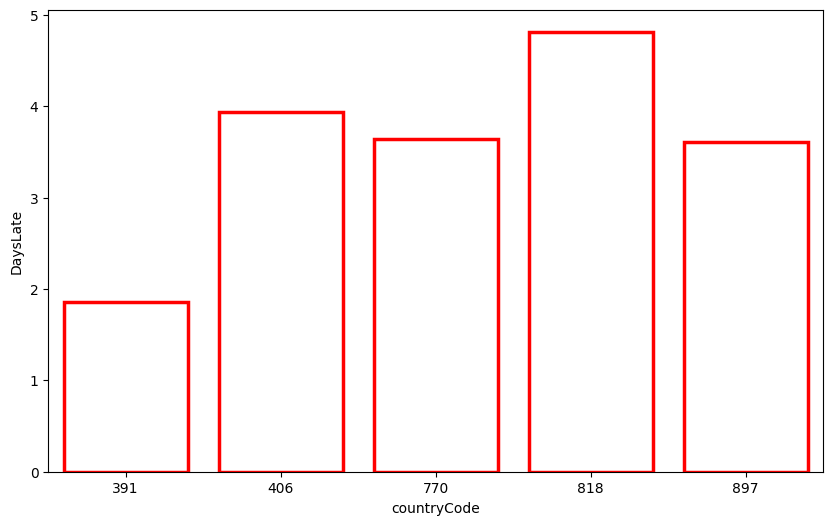

In [14]:

temp = df_receivable.groupby('countryCode', as_index=False)['DaysLate'].mean()

plt.figure(figsize=(10,6))
sns.barplot(x="countryCode", y="DaysLate",data=temp,linewidth=2.5, facecolor=(1, 1, 1, 0),
                 errcolor=".4", edgecolor="red")

Identified that country code 818 has maxiimum lateday and minimum late days for 391.<br>
Check the details of categorical features

In [16]:
df_receivable.describe(include= 'object')

C:\Users\rborehal\AppData\Local\Temp\ipykernel_31508\650958861.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_receivable.describe(include= 'object')


,customerID,PaperlessDate,DueDate,Disputed,SettledDate,PaperlessBill
count,2466,2466,2466,2466,2466,2466
unique,100,91,681,2,695,2
top,9149-MATVB,3/3/2012,1/29/2013,No,5/28/2013,Paper
freq,36,58,10,1905,10,1263


Count of categorical features

In [17]:
print(pd.crosstab(index=df_receivable["PaperlessBill"], columns="count"))
print(pd.crosstab(index=df_receivable["countryCode"], columns="count"))
print(pd.crosstab(index=df_receivable["Late"], columns="count"))

col_0          count
PaperlessBill       
Electronic      1203
Paper           1263
col_0        count
countryCode       
391            616
406            561
770            506
818            387
897            396
col_0  count
Late        
0       1589
1        877


Checking for the customer who is late to pay

In [18]:
df_receivable.head(3)

,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate,Late,countlate
0,391,0379-NEVHP,4/6/2013,611365,2013-01-02,2/1/2013,55.94,No,1/15/2013,Paper,13,0,0,0
1,406,8976-AMJEO,3/3/2012,7900770,2013-01-26,2/25/2013,61.74,Yes,3/3/2013,Electronic,36,6,1,0
2,391,2820-XGXSB,1/26/2012,9231909,2013-07-03,8/2/2013,65.88,No,7/8/2013,Electronic,5,0,0,0


In [19]:
customer_late =pd.crosstab(index=df_receivable["customerID"], columns=df_receivable['Late'])
customer_late.sort_values(by=[1], ascending = False)

Late,0,1
customerID,,
0688-XNJRO,2,32
8690-EEBEO,5,26
8102-ABPKQ,1,26
4460-ZXNDN,3,25
6708-DPYTF,5,25
...,...,...
7695-NKUXM,19,0
8820-BLYDZ,24,0
9286-VLKMI,34,0


In [20]:
df1 = df_receivable[df_receivable['DaysLate']>0].copy()

In [21]:
df2 = df1.groupby('customerID', as_index=False)['DaysLate'].count()

In [22]:
df2.columns = (['customerID','repeatCust'])

In [23]:
df3 = pd.merge(df_receivable, df2, how='left', on='customerID')

In [24]:
df3['repeatCust'].fillna(0, inplace=True)

C:\Users\rborehal\AppData\Local\Temp\ipykernel_31508\1188047504.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df3['repeatCust'].fillna(0, inplace=True)


0        1.0
1        5.0
2        0.0
3       17.0
4        9.0
        ... 
2461    25.0
2462     2.0
2463     7.0
2464     5.0
2465     4.0
Name: repeatCust, Length: 2466, dtype: float64

In [25]:
df_receivable = df3

<Axes: xlabel='repeatCust', ylabel='DaysLate'>

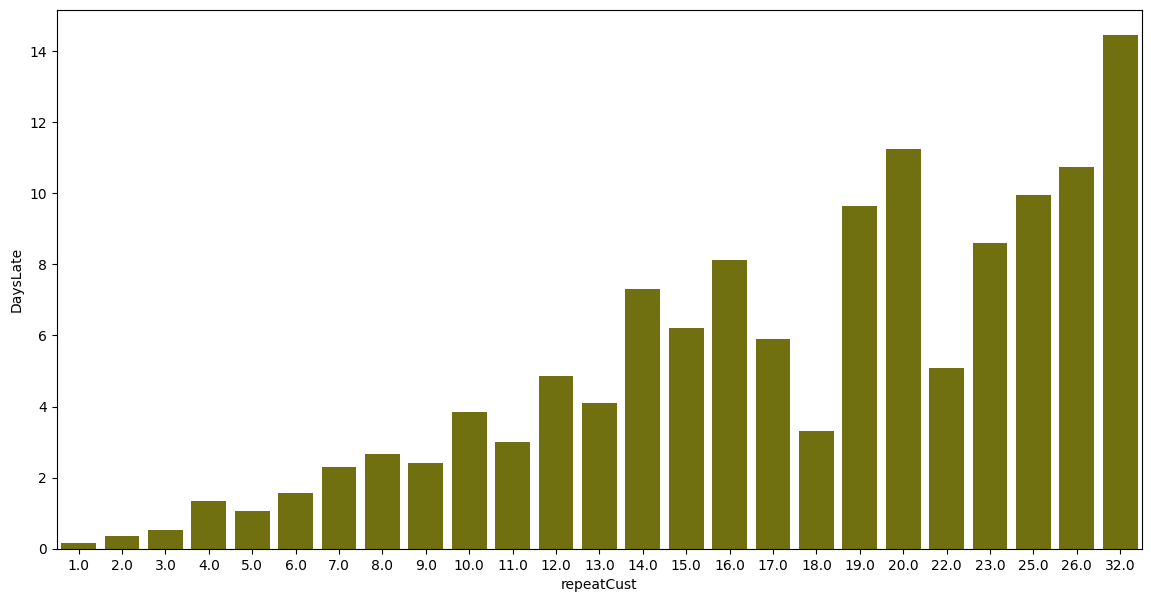

In [26]:

temp = df_receivable.groupby(['repeatCust'], as_index=False)['DaysLate'].mean()

plt.figure(figsize=(14,7))
sns.barplot(x="repeatCust", y="DaysLate",data=temp,color='olive')

In [27]:
def func_IA (x):
    if x>60: return "b. more than 60"
    else: return "a. less than 60"
df_receivable['InvoiceAmount_bin'] = df_receivable['InvoiceAmount'].apply(func_IA)

In [28]:
df_receivable.head(3)

,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate,Late,countlate,repeatCust,InvoiceAmount_bin
0,391,0379-NEVHP,4/6/2013,611365,2013-01-02,2/1/2013,55.94,No,1/15/2013,Paper,13,0,0,0,1.0,a. less than 60
1,406,8976-AMJEO,3/3/2012,7900770,2013-01-26,2/25/2013,61.74,Yes,3/3/2013,Electronic,36,6,1,0,5.0,b. more than 60
2,391,2820-XGXSB,1/26/2012,9231909,2013-07-03,8/2/2013,65.88,No,7/8/2013,Electronic,5,0,0,0,NaN,b. more than 60


In [29]:
temp = df_receivable.groupby(['repeatCust'], as_index=False)['DaysLate'].mean()

In [31]:
print(temp.head())

   repeatCust  DaysLate
0         1.0  0.170507
1         2.0  0.362460
2         3.0  0.531915
3         4.0  1.333333
4         5.0  1.053922


In [30]:
plt.figure(figsize=(10,6))
sns.barplot(x="InvoiceAmount_bin", y="DaysLate",data=temp,color='purple')

ValueError: Could not interpret value `InvoiceAmount_bin` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

**
Generate more features and map the some of the categorical variables to integers**<br>
Map some of the categorical variables to integers. It is also helpful to generate some more insights about a customer given the data. For example if the order occurs at the end of the year is a company more likely to pay on time?

In [32]:
df_receivable['Disputed'] = df_receivable['Disputed'].map({'No':0,'Yes':1})
df_receivable['PaperlessBill'] = df_receivable['PaperlessBill'].map({'Paper': 0,'Electronic': 1})

In [33]:
df_receivable['InvoiceQuarter']= pd.to_datetime(df_receivable['InvoiceDate']).dt.quarter

In [34]:
df_receivable.head(3)

,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate,Late,countlate,repeatCust,InvoiceAmount_bin,InvoiceQuarter
0,391,0379-NEVHP,4/6/2013,611365,2013-01-02,2/1/2013,55.94,0,1/15/2013,0,13,0,0,0,1.0,a. less than 60,1
1,406,8976-AMJEO,3/3/2012,7900770,2013-01-26,2/25/2013,61.74,1,3/3/2013,1,36,6,1,0,5.0,b. more than 60,1
2,391,2820-XGXSB,1/26/2012,9231909,2013-07-03,8/2/2013,65.88,0,7/8/2013,1,5,0,0,0,NaN,b. more than 60,3


Check for relation to late with  other variable to

In [35]:
plt.figure(figsize=(10,8))

ax = sns.countplot(df_receivable['countryCode'],hue=df_receivable['Late'],palette="YlGn")


ValueError: The following variable cannot be assigned with wide-form data: `hue`

<Figure size 1000x800 with 0 Axes>

In [36]:
plt.figure(figsize=(10,8))
sns.countplot(df_receivable['InvoiceQuarter'],hue=df_receivable['Late'],palette='bright')


ValueError: The following variable cannot be assigned with wide-form data: `hue`

<Figure size 1000x800 with 0 Axes>

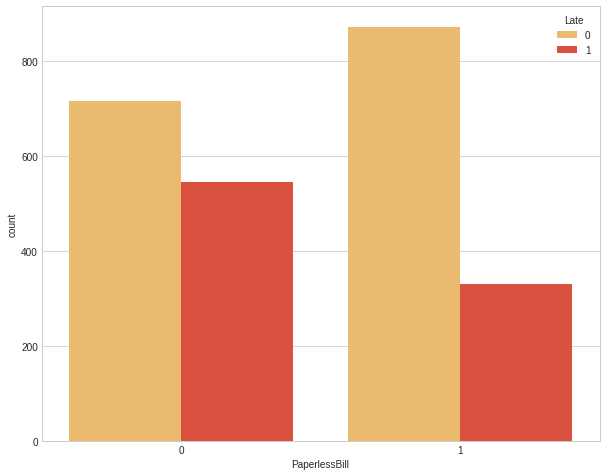

In [32]:
plt.figure(figsize=(10,8))
sns.countplot(df_receivable['PaperlessBill'],hue=df_receivable['Late'],palette='YlOrRd')


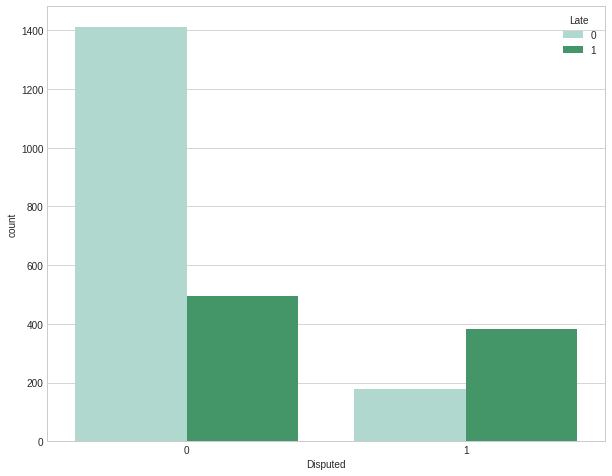

In [33]:
plt.figure(figsize=(10,8))
sns.countplot(df_receivable['Disputed'],hue=df_receivable['Late'],palette='BuGn')


### Distributions of Invoice Amounts and Days to settle
It may be useful to understand the distribution of some variables. This can be helpful if we wish to know within reasonable assumptions what our confidence intervals are for payments or how long it takes for a customer to settle.

C:\Users\rborehal\AppData\Local\Temp\ipykernel_31508\279972085.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_receivable['InvoiceAmount'],color='green')
C:\Users\rborehal\AppData\Local\Temp\ipykernel_31508\279972085.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_receivable['DaysT

<Axes: xlabel='DaysToSettle', ylabel='Density'>

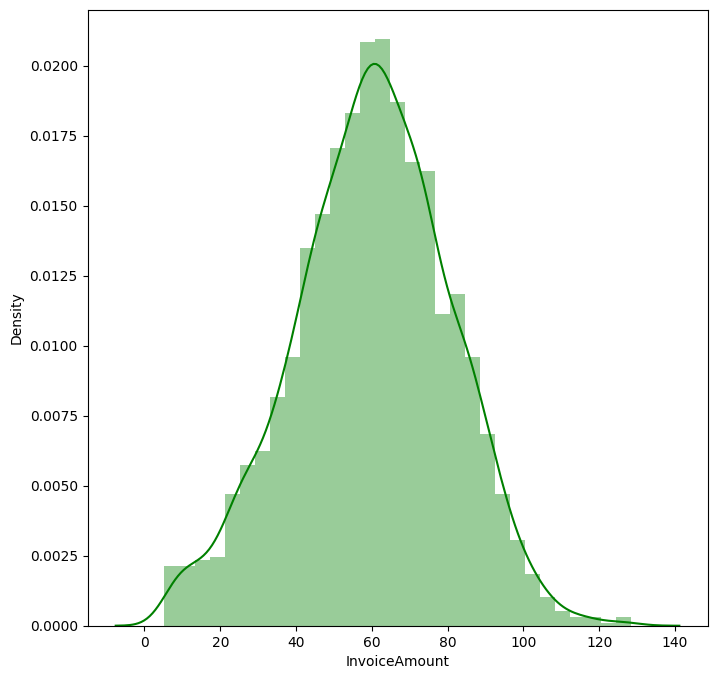

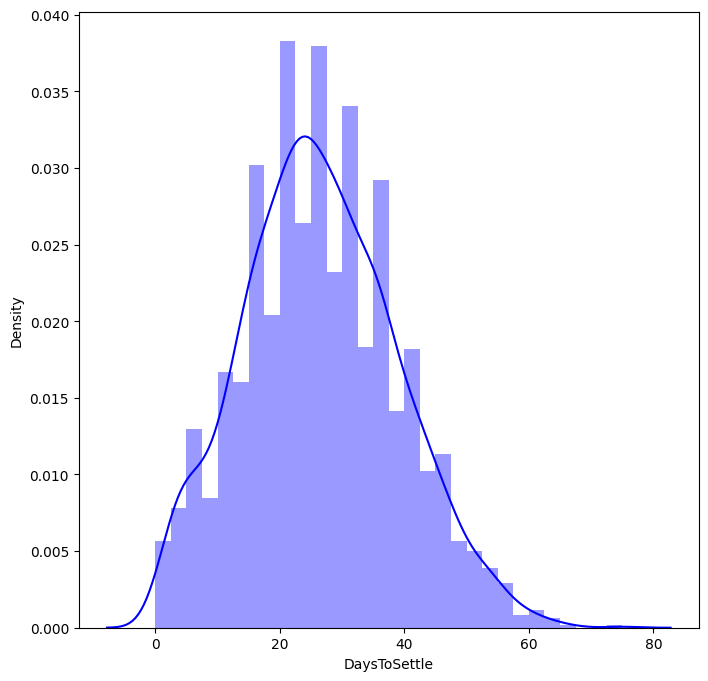

In [37]:
plt.figure(figsize=(8,8))
plt.figure(1)
sns.distplot(df_receivable['InvoiceAmount'],color='green')
plt.figure(figsize=(8,8))
plt.figure(2)
sns.distplot(df_receivable['DaysToSettle'],color='blue')


Finally, label customers with integers for processing in models

In [38]:
labels = df_receivable['customerID'].astype('category').cat.categories.tolist()

In [39]:
replace_map_comp = {'customerID' : {k: v for k,v in zip(labels,list(range(1,len(labels)+1)))}}

In [40]:
#replace the customerID with Integers
df_receivable.replace(replace_map_comp, inplace=True)

,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate,Late,countlate,repeatCust,InvoiceAmount_bin,InvoiceQuarter
0,391,2,4/6/2013,611365,2013-01-02,2/1/2013,55.94,0,1/15/2013,0,13,0,0,0,1.0,a. less than 60,1
1,406,83,3/3/2012,7900770,2013-01-26,2/25/2013,61.74,1,3/3/2013,1,36,6,1,0,5.0,b. more than 60,1
2,391,21,1/26/2012,9231909,2013-07-03,8/2/2013,65.88,0,7/8/2013,1,5,0,0,0,NaN,b. more than 60,3
3,406,92,4/6/2012,9888306,2013-02-10,3/12/2013,105.92,0,3/17/2013,1,35,5,1,0,17.0,b. more than 60,1
4,818,55,11/26/2012,15752855,2012-10-25,11/24/2012,72.27,1,11/28/2012,0,34,4,1,0,9.0,b. more than 60,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2461,391,57,8/2/2012,9982796720,2013-10-18,11/17/2013,79.61,0,12/1/2013,1,44,14,1,24,25.0,b. more than 60,4
2462,391,98,1/3/2013,9983237240,2012-09-19,10/19/2012,38.25,0,10/13/2012,0,24,0,0,2,2.0,a. less than 60,3
2463,770,72,8/5/2012,9986249860,2012-07-02,8/1/2012,67.59,0,7/27/2012,0,25,0,0,7,7.0,b. more than 60,3
2464,770,60,9/29/2012,9989225541,2012-04-27,5/27/2012,53.16,0,5/18/2012,0,21,0,0,5,5.0,a. less than 60,2


In [41]:
df_receivable.head(3)

,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate,Late,countlate,repeatCust,InvoiceAmount_bin,InvoiceQuarter
0,391,2,4/6/2013,611365,2013-01-02,2/1/2013,55.94,0,1/15/2013,0,13,0,0,0,1.0,a. less than 60,1
1,406,83,3/3/2012,7900770,2013-01-26,2/25/2013,61.74,1,3/3/2013,1,36,6,1,0,5.0,b. more than 60,1
2,391,21,1/26/2012,9231909,2013-07-03,8/2/2013,65.88,0,7/8/2013,1,5,0,0,0,NaN,b. more than 60,3



## Train a Model to Predict if a Payment will be late

In [42]:
df_receivable.head(3)

,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate,Late,countlate,repeatCust,InvoiceAmount_bin,InvoiceQuarter
0,391,2,4/6/2013,611365,2013-01-02,2/1/2013,55.94,0,1/15/2013,0,13,0,0,0,1.0,a. less than 60,1
1,406,83,3/3/2012,7900770,2013-01-26,2/25/2013,61.74,1,3/3/2013,1,36,6,1,0,5.0,b. more than 60,1
2,391,21,1/26/2012,9231909,2013-07-03,8/2/2013,65.88,0,7/8/2013,1,5,0,0,0,NaN,b. more than 60,3


In [48]:
cat_feats = ['InvoiceAmount_bin']
final_data = pd.get_dummies(df_receivable,columns=cat_feats,drop_first=True)

In [49]:
final_data.head(3)

,countryCode,customerID,PaperlessDate,invoiceNumber,InvoiceDate,DueDate,InvoiceAmount,Disputed,SettledDate,PaperlessBill,DaysToSettle,DaysLate,Late,countlate,repeatCust,InvoiceQuarter,InvoiceAmount_bin_b. more than 60
0,391,2,4/6/2013,611365,2013-01-02,2/1/2013,55.94,0,1/15/2013,0,13,0,0,0,1.0,1,False
1,406,83,3/3/2012,7900770,2013-01-26,2/25/2013,61.74,1,3/3/2013,1,36,6,1,0,5.0,1,True
2,391,21,1/26/2012,9231909,2013-07-03,8/2/2013,65.88,0,7/8/2013,1,5,0,0,0,NaN,3,True


In [50]:
features=['countryCode', 'customerID', 'InvoiceAmount',
       'Disputed', 'PaperlessBill','repeatCust','Late', 'DaysToSettle',
       'countlate']

In [51]:
features

['countryCode',
 'customerID',
 'InvoiceAmount',
 'Disputed',
 'PaperlessBill',
 'repeatCust',
 'Late',
 'DaysToSettle',
 'countlate']

In [52]:
X = final_data[features]
y = final_data['DaysLate']

In [53]:
y.head(5)

0    0
1    6
2    0
3    5
4    4
Name: DaysLate, dtype: int64

In [54]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=0)

In [55]:
linear=LinearRegression()

In [60]:
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]   # Keep target aligned

In [61]:
linear.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [62]:
X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]   # Keep target aligned

In [69]:
# linear Regression

y_pred = linear.predict(X_test)

In [64]:
#Checking the accuracy
linear_accuracy = round(linear.score(X_train,y_train)*100,2)
print(round(linear_accuracy,2),'%')

75.21 %


In [67]:
y_test

575      0
1096    18
715      5
1023    17
2210     0
        ..
1679     0
720      0
342      0
1315    15
1549     0
Name: DaysLate, Length: 517, dtype: int64

In [70]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_test,y_pred)

10.727705149684107

II. Testing the same model with Gradient Boosting Regression

In [88]:
GBR_model = GradientBoostingRegressor(n_estimators=100, max_depth=4)

In [89]:
#Fit
GBR_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [90]:
y_pred2 = GBR_model.predict(X_test)

In [91]:
#Checking the accuracy
GBR_model_accuracy = round(GBR_model.score(X_train,y_train)*100,2)
print(round(GBR_model_accuracy,2),'%')

100.0 %


In [92]:
mean_squared_error(y_test,y_pred2)

0.0007583892692382796

III. Trying model with more estimators

In [76]:
random_model = RandomForestRegressor(n_estimators=1000)

In [77]:
#Fit
random_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [78]:
y_pred3 = random_model.predict(X_test)

In [79]:
#Checking the accuracy
random_model_accuracy = round(random_model.score(X_train,y_train)*100,2)
print(round(random_model_accuracy,2),'%')

99.98 %


In [80]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_test,y_pred3)

0.0004971798839458394